<a href="https://colab.research.google.com/github/pressleydavid/hw5/blob/main/HW6_ST554_DavidPressley.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# HW6
**David Pressley**

**Course:** ST554

**Due:** March 3, 2026  

**Submission:** Save to GitHub repo, submit repo link on Moodle

The purpose of this homework is to get a little more practice with SQL and gain some practice with creating classes.

**Instructions:**
- Include markdown text describing what you are doing, even when not explicitly asked for
- Add comments to .py file explaining work
- Save updates to GitHub as you work through it
- No edits after the due date
- check sharing settings
- use hw5 repo. Develop on main.

In [ ]:
# import ability to use Markdown in Code Cell displays
from IPython.display import display, Markdown

## Part I - More Practice Querying a Database (16 pts)
The purpose of this homework is to get a little more practice with SQL and gain some practice with creating classes.

### Question 1
Connect to the database and then look at all of the tables in the database (use `read_sql()` from `pandas` to have this returned as a data frame). (2 pts)

In [ ]:
import pandas as pd
import sqlite3
import urllib.request

url = "https://github.com/jknecht/baseball-archive-sqlite/releases/download/2022/lahman_1871-2022.sqlite"
output_file = "lahman.sqlite"

urllib.request.urlretrieve(url, output_file)

con = sqlite3.connect('lahman.sqlite')
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", con)
display(Markdown(f"### Tables in the Lahman Database"))
print(tables)


### Tables in the Lahman Database

                   name
0           AllstarFull
1           Appearances
2        AwardsManagers
3         AwardsPlayers
4   AwardsShareManagers
5    AwardsSharePlayers
6               Batting
7           BattingPost
8        CollegePlaying
9              Fielding
10           FieldingOF
11      FieldingOFsplit
12         FieldingPost
13           HallOfFame
14            HomeGames
15             Managers
16         ManagersHalf
17                Parks
18               People
19             Pitching
20         PitchingPost
21             Salaries
22              Schools
23           SeriesPost
24                Teams
25      TeamsFranchises
26            TeamsHalf


### Question 2
Using SQL, construct a table of hall of fame pitchers (any hall of famer that pitched) that gives the `playerID` and their total (sum) for `GS`, `G`, `W`, `L`, `IPOuts`, `CG`, `SHO`, and `SV` columns. The summing can be done in `pandas` or in the SQL call. (6 pts)

In [ ]:
# LHS is HallofFame where inducted
# RHS is Pitchers
# inner join (default join) to get pitchers inducted
hof_pitchers = pd.read_sql("""
    SELECT
        l.playerID,
        l.inducted,
        SUM(r.GS) as total_games_started,
        SUM(r.G) as total_games,
        SUM(r.W) as total_wins,
        SUM(r.L) as total_losses,
        SUM(r.IPOuts) as total_outs_pitched,
        SUM(r.CG) as total_complete_games,
        SUM(r.SHO) as total_shutouts,
        SUM(r.SV) as total_saves
    FROM (
        SELECT DISTINCT playerID, inducted
        FROM HallofFame
        WHERE inducted = 'Y'
    ) as l
    INNER JOIN
    Pitching as r
    ON l.playerID = r.playerID
    GROUP BY l.playerID;
    """, con)
display(Markdown(f"### Selected totals for pitchers inducted into Hall of Fame"))
display(hof_pitchers)

### Selected totals for pitchers inducted into Hall of Fame

,playerID,inducted,total_games_started,total_games,total_wins,total_losses,total_outs_pitched,total_complete_games,total_shutouts,total_saves
0,alexape01,Y,599,696,373,208,15570,437,90,32
1,ansonca01,Y,0,3,0,1,12,0,0,1
2,bendech01,Y,334,459,212,127,9051,255,40,34
3,blylebe01,Y,685,692,287,250,14910,242,60,0
4,boggswa01,Y,0,2,0,0,7,0,0,0
...,...,...,...,...,...,...,...,...,...,...
96,willivi01,Y,471,513,249,205,11988,388,50,11
97,wrighge01,Y,0,3,0,1,15,0,0,0
98,wrighha01,Y,8,36,4,4,301,0,0,14
99,wynnea01,Y,612,691,300,244,13692,290,49,15


### Question 3
For all of the hall of fame pitchers, use SQL to create a table of their batting statistics. Namely, the `playerID` and their total (sum) for `AB`, `R`, `H`, `HR`, `RBI`, `BB`, and `SO`. The summing can be done in `pandas` or in the SQL call. (4 pts)

In [ ]:
# to get all hall of fame pitchers from sql query, we need to select records from a subsetting query for distinct players inducted as the left-hand table(l).
# then join that table with the "middle table" (m) as a junction table to bridge between HoF and Batting stats, linking them together with playerID
# finally, return the totals from the right-hand table (r)
hof_pitch_bat_stat = pd.read_sql("""
    SELECT
        l.playerID,
        l.inducted,
        SUM(r.AB) as total_at_bats,
        SUM(r.R) as total_runs,
        SUM(r.H) as total_hits,
        SUM(r.HR) as total_home_runs,
        SUM(r.RBI) as total_RBI,
        SUM(r.BB) as total_base_on_balls,
        SUM(r.SO) as total_strike_outs
    FROM (
        SELECT DISTINCT playerID, inducted
        FROM HallofFame
        WHERE inducted = 'Y'
    ) as l
    INNER JOIN (
        SELECT DISTINCT playerID FROM pitching
    ) as m
        ON l.playerID = m.playerID
    INNER JOIN Batting as r
        ON l.playerID = r.playerID
    GROUP BY l.playerID;
    """, con)
display(Markdown(f"### Selected batting totals for pitchers inducted into Hall of Fame"))
display(hof_pitch_bat_stat)


### Selected batting totals for pitchers inducted into Hall of Fame

,playerID,inducted,total_at_bats,total_runs,total_hits,total_home_runs,total_RBI,total_base_on_balls,total_strike_outs
0,alexape01,Y,1810,154,378,11,163,77,276
1,ansonca01,Y,10281,1999,3435,97,2075,984,330
2,becklja01,Y,9551,1603,2938,87,1581,616,526
3,bendech01,Y,1147,102,243,6,116,75,143
4,blylebe01,Y,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...,...
103,willivi01,Y,1493,107,248,1,84,81,199
104,wrighge01,Y,2873,665,866,11,326,68,119
105,wrighha01,Y,813,183,224,4,113,37,14
106,wynnea01,Y,1704,136,365,17,173,141,330


### Question 4
Using `pandas` join the previous two tables together by pitcher. (If you want, try to do all of this via SQL! Not required though, feel free to use `pd.merge()` if you'd like) (4 pts)

In [ ]:
combined_hof_stats = pd.merge(
    hof_pitchers,
    hof_pitch_bat_stat,
    on = ['playerID','inducted'],
    how = 'outer'
)
display(Markdown(f"### Combined totals for pitching and batting for pitchers inducted into Hall of Fame"))
display(combined_hof_stats)

### Combined totals for pitching and batting for pitchers inducted into Hall of Fame

,playerID,inducted,total_games_started,total_games,total_wins,total_losses,total_outs_pitched,total_complete_games,total_shutouts,total_saves,total_at_bats,total_runs,total_hits,total_home_runs,total_RBI,total_base_on_balls,total_strike_outs
0,alexape01,Y,599.0,696.0,373.0,208.0,15570.0,437.0,90.0,32.0,1810,154,378,11,163,77,276
1,ansonca01,Y,0.0,3.0,0.0,1.0,12.0,0.0,0.0,1.0,10281,1999,3435,97,2075,984,330
2,becklja01,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9551,1603,2938,87,1581,616,526
3,bendech01,Y,334.0,459.0,212.0,127.0,9051.0,255.0,40.0,34.0,1147,102,243,6,116,75,143
4,blylebe01,Y,685.0,692.0,287.0,250.0,14910.0,242.0,60.0,0.0,451,19,59,0,25,5,193
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
103,willivi01,Y,471.0,513.0,249.0,205.0,11988.0,388.0,50.0,11.0,1493,107,248,1,84,81,199
104,wrighge01,Y,0.0,3.0,0.0,1.0,15.0,0.0,0.0,0.0,2873,665,866,11,326,68,119
105,wrighha01,Y,8.0,36.0,4.0,4.0,301.0,0.0,0.0,14.0,813,183,224,4,113,37,14
106,wynnea01,Y,612.0,691.0,300.0,244.0,13692.0,290.0,49.0,15.0,1704,136,365,17,173,141,330


## Part II - Messing with Classes

### Question 5
Create a class called `SLR_slope_simulator` that encapsulates the simulation of the sampling distribution of the slope estimator.

Recall we assume the following model for SLR:

$$Y_i = \beta_0 + \beta_1 x_i + E_i$$

where the $E_i$ are assumed to be independent and identically distributed from a Normal distribution with mean 0 and variance $\sigma^2$.

#### Class Definition

Define the `SLR_slope_simulator` class with:
- `__init__`: arguments `self`, `beta_0`, `beta_1`, `x`, `sigma`, and `seed`. Create initial attributes of `beta_0`, `beta_1`, `sigma`, `x`, `n`, `rng`, and `slopes` (an empty list).
- `generate_data`: generates one dataset (returning x and y)
- `fit_slope`: takes in x and y, fits SLR model, returns estimated slope
- `run_simulations`: takes number of simulations, uses `generate_data()` and `fit_slope()` in a loop, modifies `slopes` attribute
- `plot_sampling_distribution`: checks if slopes has length > 0, plots histogram if so
- `find_prob`: takes a `value` and `sided` argument ("above", "below", or "two-sided") and approximates the corresponding probability

In [47]:
#import  modules needed
import matplotlib.pyplot as plt
import numpy as np
from numpy.random import default_rng
from sklearn import linear_model


class SLR_slope_simulator:
    """
    Simulates the sampling distribution of the SLR slope estimator
    Parameters:
        - beta_0: true y-intercept of the SLR model
        - beta_1: true slope of the SLR model
        - x: numpy array of predictor values
        - sigma: standard deviation of the error terms (E_i)
        - seed: seed for the random number generator (for reproducibility)
    """

    # Initializer
    def __init__(self, beta_0, beta_1, x, sigma, seed):
        # create model parameters as attributes
        self.beta_0 = beta_0
        self.beta_1 = beta_1
        self.sigma = sigma
        self.x = x
        self.n = len(x)
        # create random number generator from seed
        self.rng = default_rng(seed)
        # initialize slope as empty list for slope estimator
        self.slopes = []

    #generate one dataset, return (x, y)
    def generate_data(self):
        """ Generate one dataset from the SLR model
            Return x and y arrays based on
        """
        y = self.beta_0 + self.beta_1*self.x + self.sigma*self.rng.standard_normal(self.n)
        return self.x, y

    def fit_slope(self, x, y):
        """ Fit and SLR model to x and y. Return fitted slope """
        # takes (x, y), fits SLR model, returns estimated slope
        reg = linear_model.LinearRegression()
        fit = reg.fit(x.reshape(-1,1), y)
        return fit.coef_[0]

    # takes number of simulations (n), calls generate_data() and fit_slope()
    # modifies slopes
    def run_simulations(self, num_sims):
        """ run num_sims simulations
            store estimated slopes

            uses generate_data() and fit_slopes() in a loop
            Replace slopes with array of slope estimates.
        """
        slope_list = []

        for i in range(num_sims):
            x, y = self.generate_data()
            slope = self.fit_slope(x,y)
            slope_list.append(slope)

        #convert to numpy array for later
        self.slopes = np.array(slope_list)


    # plot_sampling_distribution: checks if slopes has length > 0, plots histogram if so
    def plot_sampling_distribution(self):
        """ Plot Histogram of the simulated sample slopes """
        if len(self.slopes) == 0:
            print("run_simulations() must be called first")
            return

        plt.hist(self.slopes)
        plt.xlabel("Sample Slope")
        plt.ylabel("Frequency")
        plt.title("Sampling Distribution of Slope Estimator")

        plt.axvline(x=self.beta_1, color='red', linestyle='--', label=f"Slope (beta_1 = {self.beta_1})")
        plt.legend()
        plt.show()

    # takes a value and sided argument ("above", "below", or "two-sided") and approximates the corresponding probability
    def find_prob(self, value, sided):
        """Approximate probability based on simulated slopes.

        sided options:
          "above" = P(slope > value)
          "below" = P(slope < value)
          "two-sided" = P(|slope| > |value|)
        """
        if len(self.slopes) == 0:
            print("run_simulations() must be called first")
            return
        if sided == "above":
            return (self.slopes > value).mean()
        elif sided == "below":
            return (self.slopes < value).mean()
        elif sided == "two-sided":
            return (np.abs(self.slopes) > abs(value)).mean()



#### Testing the Class

Create an instance of the object with `beta_0 = 12`, `beta_1 = 2`, `x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)`, `sigma = 1`, and `seed = 10`.

In [48]:
# Create the x values as a (33 row,0 column) numpy array. (three copies of 0-10 sequence, same as HW5)
x = np.array(list(np.linspace(start = 0, stop = 10, num = 11))*3)

# Instantiate the simulator
sim = SLR_slope_simulator(beta_0 = 12, beta_1 = 2, x = x, sigma = 1, seed = 10)
print(f"Simulation created with beta_0={sim.beta_0}, beta_1={sim.beta_1}, n={sim.n}")
type(sim)


Simulation created with beta_0=12, beta_1=2, n=33


__main__.SLR_slope_simulator

#### Call `run_simulations()` before running simulations (should return error message)

In [49]:
# This should print the error message since no simulations have been run yet
sim.plot_sampling_distribution()

run_simulations() must be called first


#### Run 10,000 simulations

In [50]:
# Run 10,000 simulations to approximate the sampling distribution of the slope
sim.run_simulations(10000)

#### Plot the sampling distribution

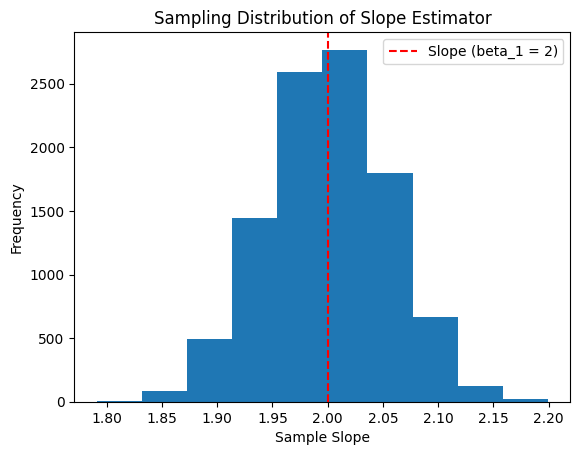

In [51]:
# Plot histogram of the 10,000 simulated slope estimates
sim.plot_sampling_distribution()

#### Approximate the two-sided probability of being larger than 2.1

In [52]:
# Approximate 2-sided p(slope > 2.1)
prob = sim.find_prob(2.1,"two-sided")
print(f"Two-sided probability of being larger than 2.1: {prob}")

Two-sided probability of being larger than 2.1: 0.0352


#### Print out the simulated slopes

In [53]:
# print array of slopes from slopes attribute.
print(sim.slopes)

[2.0239168  1.99560551 2.04249093 ... 1.93451109 2.01445559 2.07173587]
